1. Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

2. Load Dataset

In [2]:
# load Data set from Kaggle

import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")

print("Path to dataset files:", path)

df= pd.read_csv(os.path.join(path, "AB_NYC_2019.csv"))
df.head()

Path to dataset files: C:\Users\conta\.cache\kagglehub\datasets\dgomonov\new-york-city-airbnb-open-data\versions\3


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [4]:
#df.describe()
df.describe(include="all")

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,48879,4.889500e+04,48874,48895,48895,48895.000000,48895.000000,48895,48895.000000,48895.000000,48895.000000,38843,38843.000000,48895.000000,48895.000000
unique,NaN,47905,NaN,11452,5,221,NaN,NaN,3,NaN,NaN,NaN,1764,NaN,NaN,NaN
top,NaN,Hillside Hotel,NaN,Michael,Manhattan,Williamsburg,NaN,NaN,Entire home/apt,NaN,NaN,NaN,2019-06-23,NaN,NaN,NaN
freq,NaN,18,NaN,417,21661,3920,NaN,NaN,25409,NaN,NaN,NaN,1413,NaN,NaN,NaN
mean,1.901714e+07,NaN,6.762001e+07,NaN,NaN,NaN,40.728949,-73.952170,NaN,152.720687,7.029962,23.274466,NaN,1.373221,7.143982,112.781327
std,1.098311e+07,NaN,7.861097e+07,NaN,NaN,NaN,0.054530,0.046157,NaN,240.154170,20.510550,44.550582,NaN,1.680442,32.952519,131.622289
min,2.539000e+03,NaN,2.438000e+03,NaN,NaN,NaN,40.499790,-74.244420,NaN,0.000000,1.000000,0.000000,NaN,0.010000,1.000000,0.000000
25%,9.471945e+06,NaN,7.822033e+06,NaN,NaN,NaN,40.690100,-73.983070,NaN,69.000000,1.000000,1.000000,NaN,0.190000,1.000000,0.000000
50%,1.967728e+07,NaN,3.079382e+07,NaN,NaN,NaN,40.723070,-73.955680,NaN,106.000000,3.000000,5.000000,NaN,0.720000,1.000000,45.000000
75%,2.915218e+07,NaN,1.074344e+08,NaN,NaN,NaN,40.763115,-73.936275,NaN,175.000000,5.000000,24.000000,NaN,2.020000,2.000000,227.000000


In [5]:
df.shape

(48895, 16)

# 3. EDA - Exploraoty Data Analysis

3.1 Missing values

In [6]:
missing = df.isnull().sum()
missing[missing>0]

name                    16
host_name               21
last_review          10052
reviews_per_month    10052
dtype: int64

3.2 Target variable room_type

In [7]:
df['room_type'].unique()

<ArrowStringArray>
['Private room', 'Entire home/apt', 'Shared room']
Length: 3, dtype: str

In [8]:
df['room_type'].value_counts()

# Shared Room is very less in no. So our model can get biased towards other two data having larger and comparable values.
# We need to fix this biasness.

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

3.3 Univariate Analysis - Numerical

array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'minimum_nights'}>],
       [<Axes: title={'center': 'number_of_reviews'}>,
        <Axes: title={'center': 'reviews_per_month'}>],
       [<Axes: title={'center': 'calculated_host_listings_count'}>,
        <Axes: title={'center': 'availability_365'}>]], dtype=object)

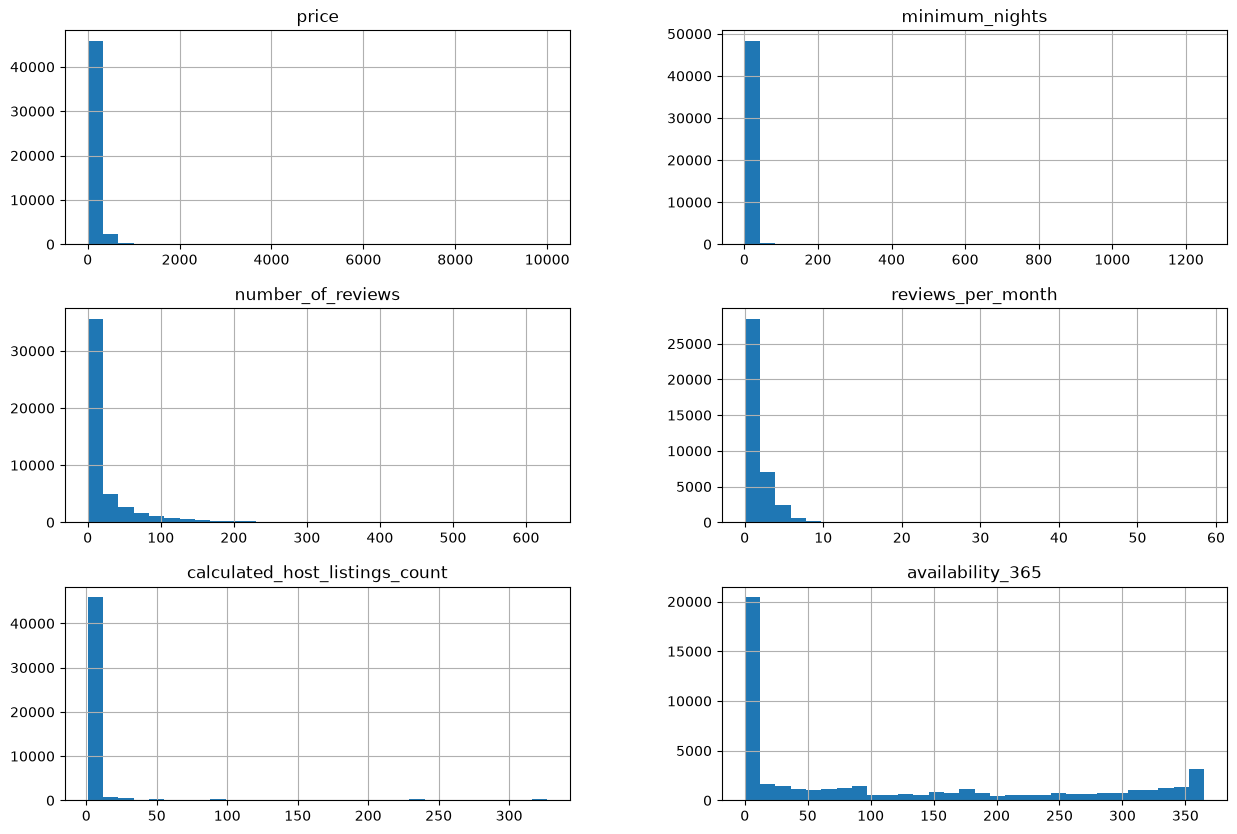

In [9]:
numerical_cols = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

# categorical_cols = ['neighbourhood_group', 'neighbourhood', 'room_type

df[numerical_cols].hist(figsize=(15,10), bins=30)
# histogram tells frequency of a particular data / feature.

# right skewness in all except last
# multi-peak distribution for availability_365
# outlier detection
# business insights

3.4 Bivariate Analysis - Feature vs Target

<Axes: xlabel='room_type', ylabel='price'>

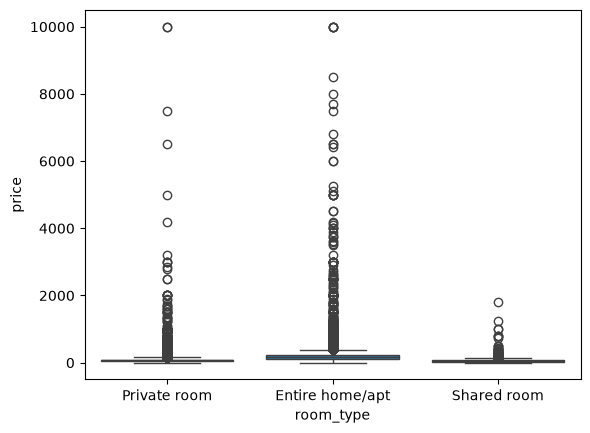

In [10]:
sns.boxplot(x='room_type', y='price', data=df)

# outliers in data

3.5 Correlation between Numeric Features

<Axes: >

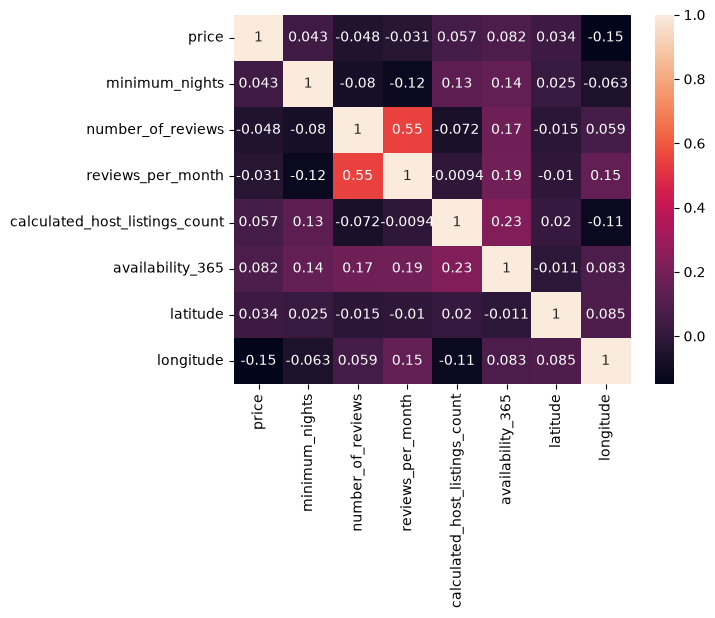

In [11]:
corr = df[numerical_cols + ['latitude' , 'longitude']].corr()
sns.heatmap(corr, annot=True)


3.6 Geographical Analysis

<Axes: xlabel='longitude', ylabel='latitude'>

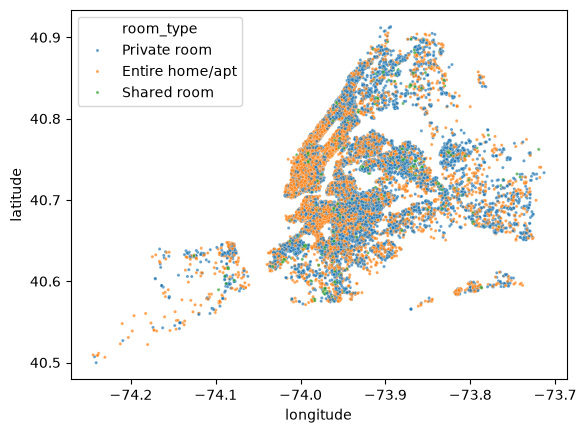

In [12]:
sns.scatterplot(x='longitude', y='latitude', data=df, hue='room_type', alpha=0.7, s=5)

Data Cleaning & Feature Engineering

In [13]:
# Drop cols that dont help us.

df_clean = df.drop(['id', 'name', 'host_name', 'last_review'], axis=1)
df_clean.head()



,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,2787,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,2845,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,4632,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,1,365
3,4869,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,7192,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0


In [14]:
# fill in the missing values. replace them by zero, review section.

df_clean['reviews_per_month'] = df_clean['reviews_per_month'].fillna(0)
df_clean.isnull().sum()

host_id                           0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

In [15]:
#3. Cap Extreme outliers instead of deleting rows.

price_cap  = df_clean['price'].quantile(0.99)
nights_cap = df_clean['minimum_nights'].quantile(0.99)

df_clean['price'] = df_clean['price'].clip(upper=price_cap)
df_clean['minimum_nights'] = df_clean['minimum_nights'].clip(upper=nights_cap)


# df_clean = df_clean[df_clean['price'] < price_cap]
# df_clean = df_clean[df_clean['minimum_nights'] < nights_cap]

In [16]:
X = df_clean.drop(columns=['room_type'])
y = df_clean['room_type']

Train test split

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


# Use of stratify=y

stratify=y tells sklearn:

“When splitting the data, maintain approximately the same class proportions in both the training and testing sets as in the original dataset.”


**stratify=y = preserve the distribution of y while splitting.**


this important in classification
Especially when classes are imbalanced.


For example, suppose your classification dataset has:

Class	Original
1. Entire home	70%
2. Private room	25%
3. Shared room	5%


Without stratification, random splitting might produce:

Train:
1. Entire       71%
2. Private      24%
3. Shared        5%

Test:
1. Entire       65%
2. Private      30%
3. Shared        5%

With:

stratify=y

you get approximately:

Train:
1. Entire       70%
2. Private      25%
3. Shared        5%

Test:
1. Entire       70%
2. Private      25%
3. Shared        5%

So you're preserving the class distribution.

# Stratify in regression

Yes, indirectly.

You can create bins from the continuous target.

Suppose:

y = house price

You could create price groups:

1. 0–100k
2. 100–200k
3. 200–300k
4. 300–500k
5. 500k+

Then stratify based on those groups.

Conceptually:

price_bins = pd.qcut(y, q=5, labels=False)

train_test_split(
    X, y,
    test_size=0.2,
    stratify=price_bins,
    random_state=42
)

Now you're saying:

“Keep the distribution of low-, medium-, and high-priced houses approximately similar in train and test.”

That's regression stratification by bins, rather than directly stratifying on continuous y.

# Preprocessing: ColumnTransformer + Pipeline

In [18]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer

In [19]:
numerical_cols = ["latitude","longitude","price", "minimum_nights", "number_of_reviews",
                 "reviews_per_month", "calculated_host_listings_count",
                 "availability_365"]

categorical_cols = ['neighbourhood_group', 'neighbourhood']


#1. Pipeline -> for Numeric Columns
numeric_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy="median")),
    ('scale', StandardScaler())
])


#2. Pipeline -> for Categorical Columns
categorical_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy="most_frequent")),
    ('encode', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ("numerical", numeric_pipeline, numerical_cols),
    ("categorical", categorical_pipeline, categorical_cols )
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``

# SMOTE (Synthetic Minority Oversampling).
for class IMbalance
1. High chances of Overfitting.
2. Data Leakage

In [20]:
import warnings
warnings.filterwarnings('ignore')

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

In [22]:
# class_weight="Balanced" tells the model to pay more attention to the minority class
# or rare class (Shared Room)
# but the problem is GradintBossting doesnt support class weight so we left it as it is.

models = {
    "Logistic Regression" : LogisticRegression(class_weight="balanced",random_state=42),
    "Decision Tree"       : DecisionTreeClassifier(class_weight="balanced",random_state=42),
    "Random Forest"       : RandomForestClassifier(class_weight="balanced", random_state=42),
    "Gradient Boosting"   : GradientBoostingClassifier(random_state=42),
}

for name, model in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", model)])

    # Accuracy alone can be misleading on imbalanced classes, so we use macro f1
    # both: plain accuracy and macro f1 (which treats every class equally)

    accuracy = cross_val_score(pipe, X_train, y_train,cv=3,scoring="accuracy")
    macrof1 = cross_val_score(pipe, X_train, y_train,cv=3,scoring="f1_macro")

    print(f"{name} -> Accuracy: {accuracy.mean():.3f} , F1: {macrof1.mean():.3f}")

Logistic Regression -> Accuracy: 0.663 , F1: 0.526
Decision Tree -> Accuracy: 0.784 , F1: 0.650
Random Forest -> Accuracy: 0.852 , F1: 0.736
Gradient Boosting -> Accuracy: 0.850 , F1: 0.708


# Hyperparameter Tuning

In [23]:
from sklearn.model_selection import RandomizedSearchCV

best_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier",   RandomForestClassifier(class_weight='balanced'))
])

param_distribution = {
    "classifier__n_estimators" : [100,200,150,300],
    "classifier__max_depth": [8, 12, 15, 20, None],
    "classifier__min_samples_split": [2, 5, 10],
}

search = RandomizedSearchCV(
    estimator=best_pipeline,
    param_distributions=param_distribution,
    n_iter=10,
    cv=3,
    scoring="f1_macro",
    random_state=42
    )

search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...'balanced'))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__max_depth': [8, 12, ...], 'classifier__min_samples_split': [2, 5, ...], 'classifier__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also 

In [24]:
print("Best Parameters: ", search.best_params_)
print("Best CV Macro-F1: ", search.best_score_)

Best Parameters:  {'classifier__n_estimators': 150, 'classifier__min_samples_split': 5, 'classifier__max_depth': None}
Best CV Macro-F1:  0.7385653151020358


# Final Evaluation on Test set

In [25]:
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score

best_pipeline = search.best_estimator_

y_pred = best_pipeline.predict(X_test)

print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}")

print(f"F1 Score: {f1_score(y_test, y_pred, average='macro')}")

Accuracy Score: 0.8576541568667553
F1 Score: 0.761487883523826


<Axes: >

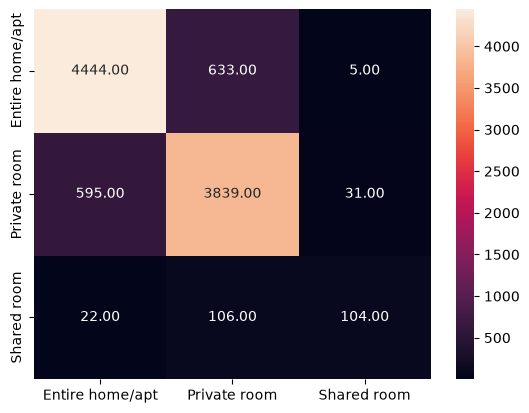

In [26]:
sns.heatmap(confusion_matrix(y_test,y_pred), annot=True, fmt=".2f",
            xticklabels=best_pipeline.classes_, yticklabels=best_pipeline.classes_)

# Saving Final Model Artifact

In [27]:
import joblib

joblib.dump(best_pipeline, "Model_Pipeline.pkl",compress=3)

['Model_Pipeline.pkl']